In [1]:
%run general_functions.ipynb

In [2]:
variables = { 
    'Sea Surface Temperature' : {'var_glodap':'temperature', 'var_name':'SST', 'var_nemo':'sosstsst', 'unit':r'$^\circ$C', 'vmin':0, 'vmax':17, 'v_chg':7.5},
    'Surface Alkalinity' :      {'var_glodap':'TAlk', 'var_name':'ALK', 'var_nemo':'ALK', 'unit':r'μ mol $\mathregular{kg^{1}}$', 'vmin':2050, 'vmax':2350, 'v_chg':100},
    'Surface Salinity' :        {'var_glodap':'salinity', 'var_name':'SSS', 'var_nemo':'sosaline', 'unit':'psu', 'vmin':31, 'vmax':38, 'v_chg':5},
    'Surface DIC' :             {'var_glodap':'PI_TCO2', 'var_name':'DIC', 'var_nemo':'DIC', 'unit':r'μ mol $\mathregular{kg^{1}}$', 'vmin':1850, 'vmax':2050, 'v_chg':100},
}

In [3]:
def discretised_cmap(ds_in):
    
    vmin, vmax = float(np.nanmin(ds_in.values)), float(np.nanmax(ds_in.values))
    if vmin < 0 <= vmax:
        vmax_abs = max(abs(vmin), abs(vmax))
        vmin, vmax = -vmax_abs, vmax_abs
        cmap, extend = cm.prinsenvlag_r, 'both'
    else:
        cmap, extend = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True), 'max'
    cmap, norm = create_discrete_cmap(cmap, 20)

    return cmap, extend

In [4]:
mesh_mask = xr.open_dataset(data_path+'mesh_mask.nc')
polygon_boundaries = polygon_mask(mesh_mask)
mesh = (mesh_mask['tmask'] * polygon_boundaries)
mesh_mask_sliced = mesh.sel(x=slice(519, 595), y=slice(329, 435)).isel(t=0,z=0)
contour= mesh_mask['tmask'].sel(x=slice(519, 595), y=slice(329, 435)).isel(t=0,z=0)

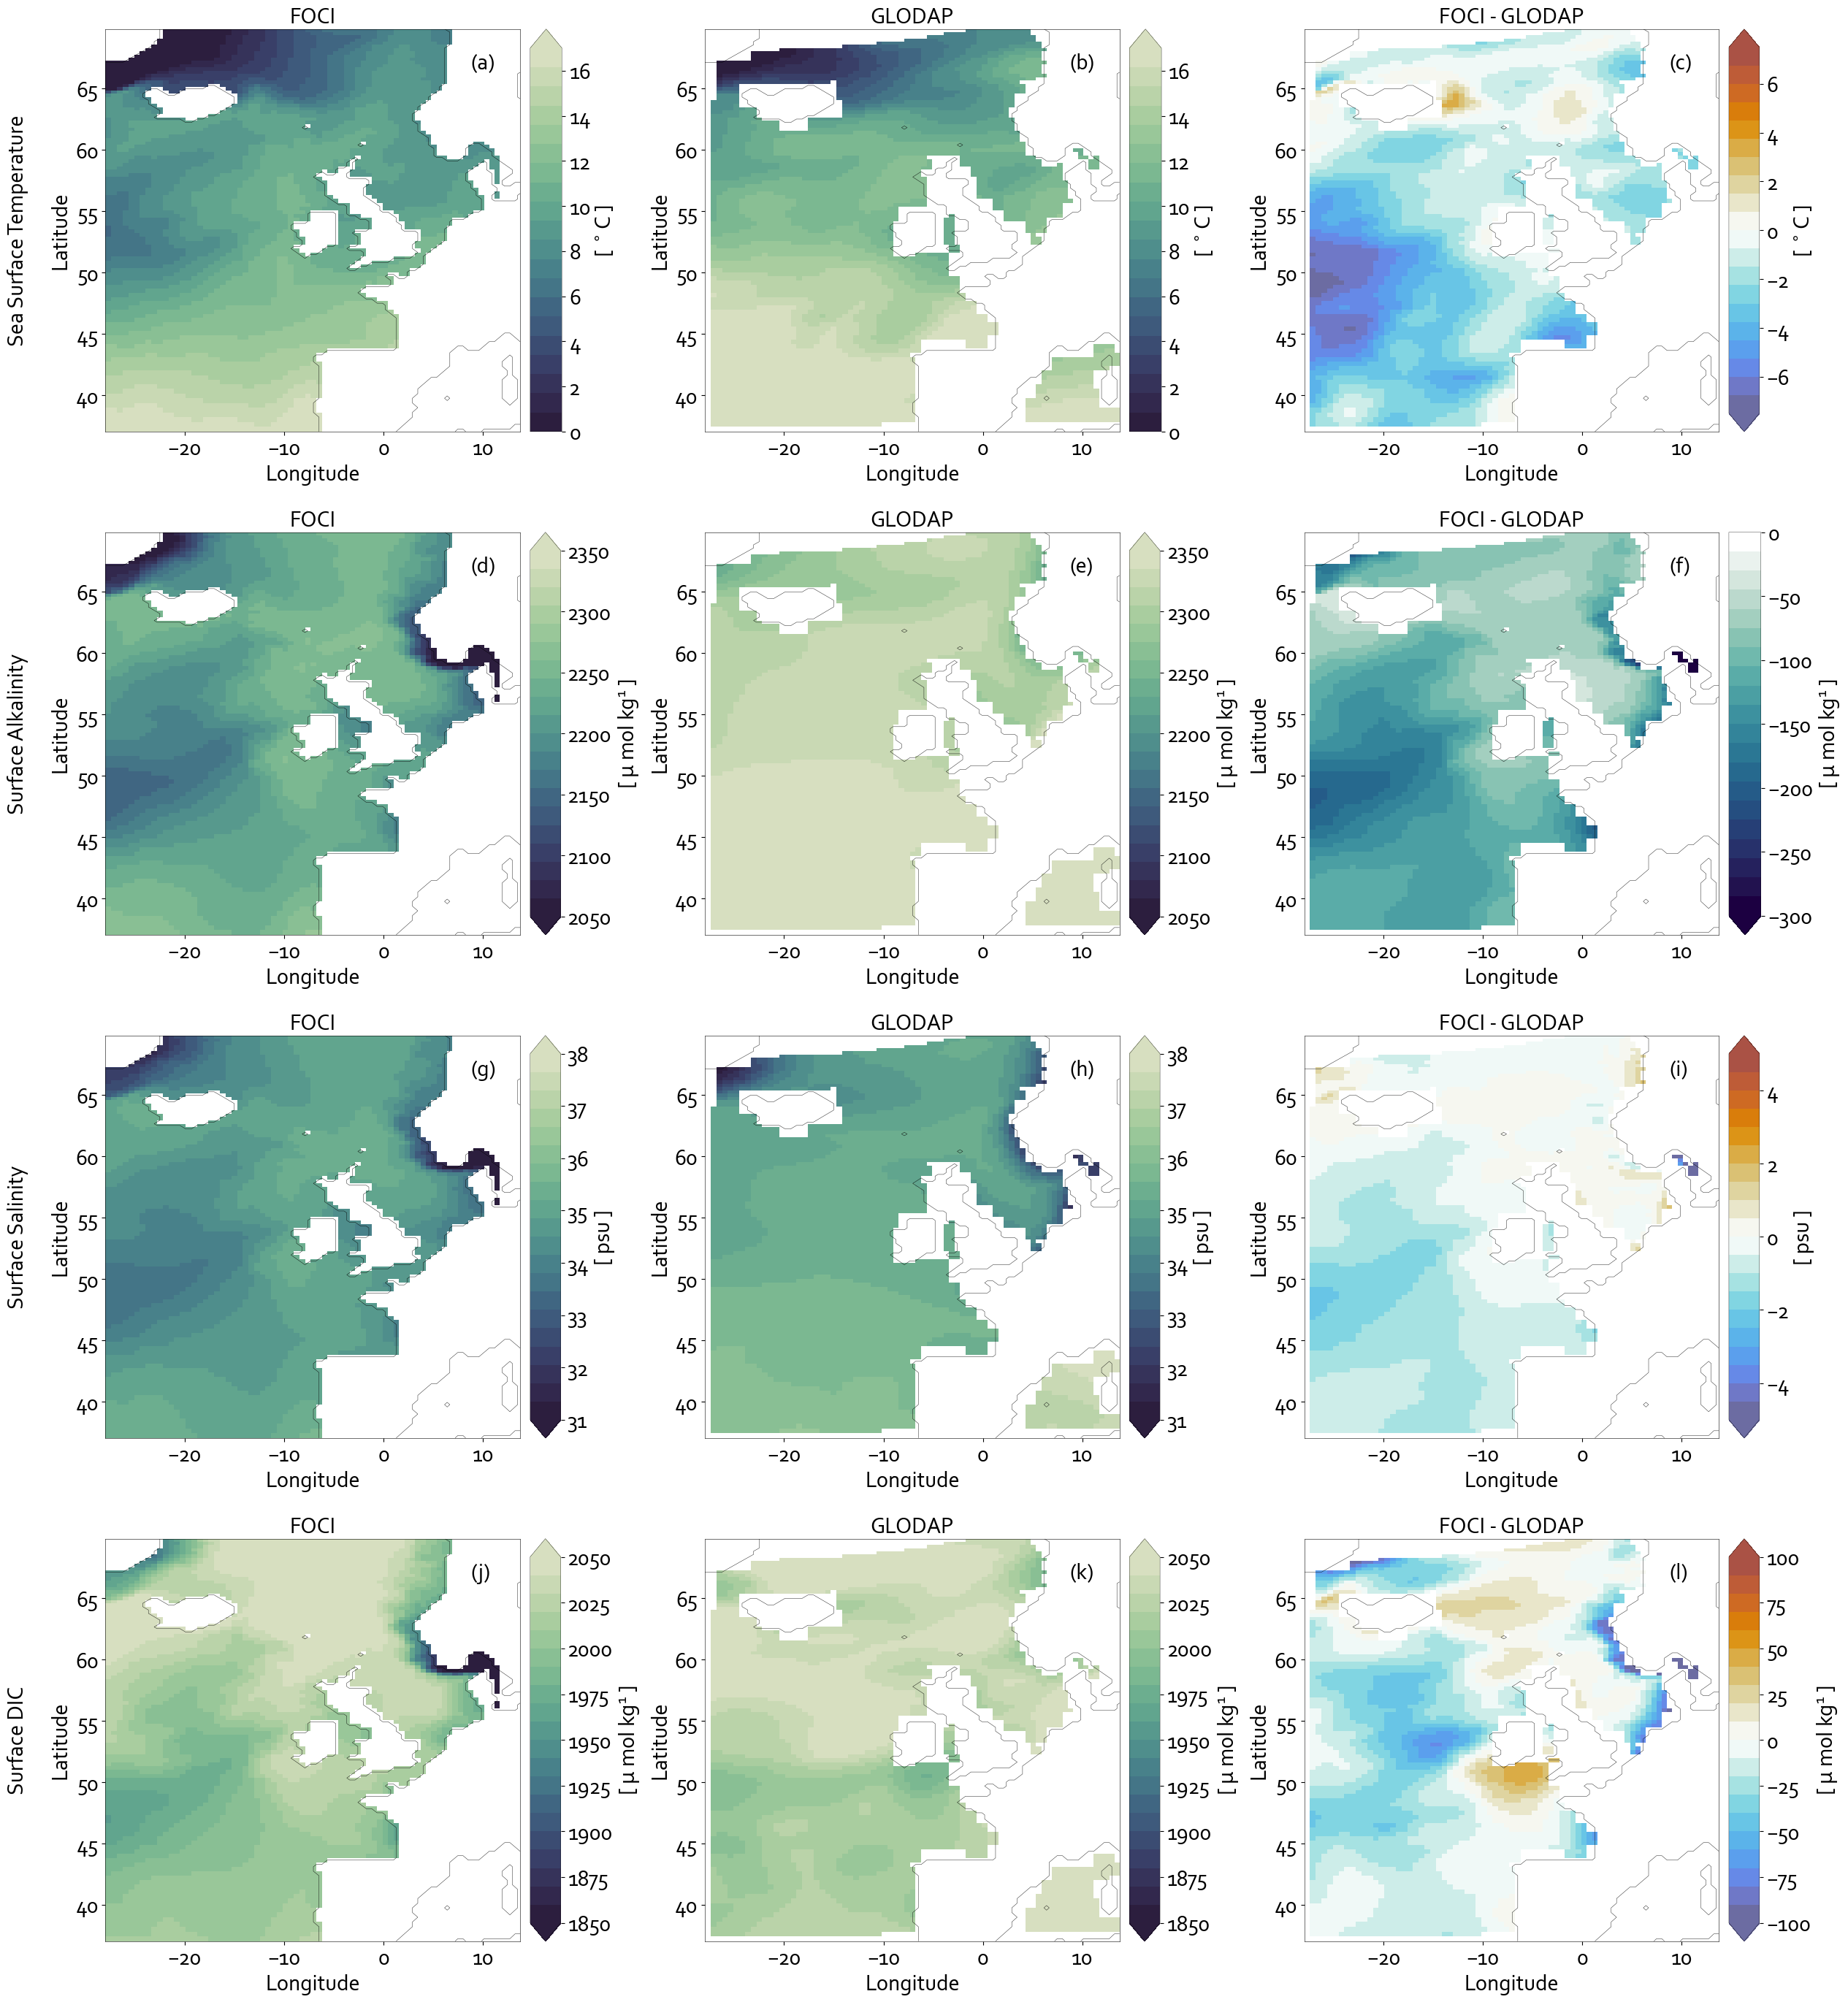

In [8]:
GLODAP_fin = {}
FOCI_fin = {}

fig, axes = plt.subplots(4,3, figsize=(30,34))
plt.subplots_adjust(hspace=0.25)

f=22

for j, (name, keys) in enumerate(variables.items()):
    
    var_glodap = keys['var_glodap']
    var_name = keys['var_name']
    var_nemo = keys['var_nemo']
    unit = keys['unit']
    
    GLODAP_fin[var_name] = {}
    FOCI_fin[var_name] = {}
        
    path = '/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/datasets/' 
    GLODAP = xr.open_dataset(path+f'GLODAPv2.2016b_MappedClimatologies/GLODAPv2.2016b.{var_glodap}.nc')
    if var_name in ['ALK','DIC','PO4']:
        FOCI = xr.open_mfdataset(path+f'data_for_chiara/{var_name}_upper100m_cut/*.nc').isel(deptht=0)
    else: 
        FOCI = xr.open_mfdataset(path+f'data_for_chiara/{var_name}_cut/*.nc')   
    FOCI = FOCI.where(mesh_mask_sliced)
    
    GLODAP = GLODAP.assign_coords(
        lon=((GLODAP.lon + 180) % 360) - 180
    ).sortby("lon")
    
    GLODAP[var_glodap] = GLODAP[var_glodap].isel(depth_surface=0).sel(lon=slice(-27.5,13), lat=slice(37,70))
    FOCI[var_nemo] = FOCI[var_nemo].mean('time_counter')
    
    # --- Define target grid (NEMO T-grid) ---
    target_grid = xr.Dataset(
        {
            "lat": (["y", "x"], FOCI["nav_lat"].values),
            "lon": (["y", "x"], FOCI["nav_lon"].values),
        }
    )

    # --- Build regridder ---
    regridder = xe.Regridder(
        GLODAP,
        target_grid,
        method="bilinear",
        periodic=True,
    )

    # --- Horizontal interpolation ---
    var_on_nemo = regridder(GLODAP[var_glodap])    
    diff = FOCI[var_nemo] - var_on_nemo
    diff = diff.where(FOCI[var_nemo]) 
    
    GLODAP_fin[var_name] = var_on_nemo
    FOCI_fin[var_name] = FOCI[var_nemo]
    
    lat, lon = FOCI['nav_lon'].mean('y'), FOCI['nav_lat'].mean('x')
    
    titles = ['FOCI','GLODAP','FOCI - GLODAP']

    for i, (ds, title) in enumerate(zip([FOCI[var_nemo], var_on_nemo, diff], titles)): 
        ax = axes[j,i] 
        
        v = keys['v_chg']
        v_min = keys['vmin']
        v_max = keys['vmax']  
        
        if '-' in title and var_name != 'ALK':
            cmap, extend = cm.prinsenvlag_r, 'both'
        else: 
            cmap, extend = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True).reversed(), 'max'
        
        if '-' in title:
            if var_name == 'ALK':
                vmin, vmax = 0,-300
                cmap = cm.ocean
                extend = 'min'
            else:
                vmin, vmax = -v,v
        else:
            vmin, vmax = v_min,v_max
            if var_name == 'SST':
                extend = 'max'
            else: 
                extend = 'both'
            
        # cmap, extend = discretised_cmap(ds)    
        cmap, norm = create_discrete_cmap(cmap, 20)
            
        im = ax.pcolormesh(lat, lon, ds, vmin=vmin, vmax=vmax, cmap=cmap)
        ax.contour(lat, lon, contour, levels=[0.5], colors='black', linewidths=.3)
        ax.tick_params(axis='both', which='major', labelsize=f)

        
        fineline(ax,0.4)
        c_map = fig.colorbar(im, ax=ax, 
            aspect=12,
            pad=0.02,location='right', extend=extend)

        c_map.set_label(f'[ {unit} ]', fontsize=f)
        c_map.outline.set_linewidth(0.25)
        c_map.ax.tick_params(labelsize=f)

        ax.set_xlabel('Longitude', fontsize=f)
        ax.set_ylabel('Latitude', fontsize=f)
        
        ax.set_title(title, fontsize=f)

axes = axes.flatten()
for n, ax in enumerate(axes):
    ax.text(0.88, 0.9, f'({string.ascii_lowercase[n]})',
            transform=ax.transAxes, color='black', fontsize=f)
    
row_titles = variables.keys()
for i, title in enumerate(row_titles):
    row = axes.reshape(4, 3)[i]          # ith row of axes
    y = (row[0].get_position().y0 + row[0].get_position().y1) / 2

    fig.text(
        0.085, y,
        title,
        ha='center',
        va='center',
        rotation=90,
        fontsize=f,
    )
    
plt.savefig(f'/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/validation.png')

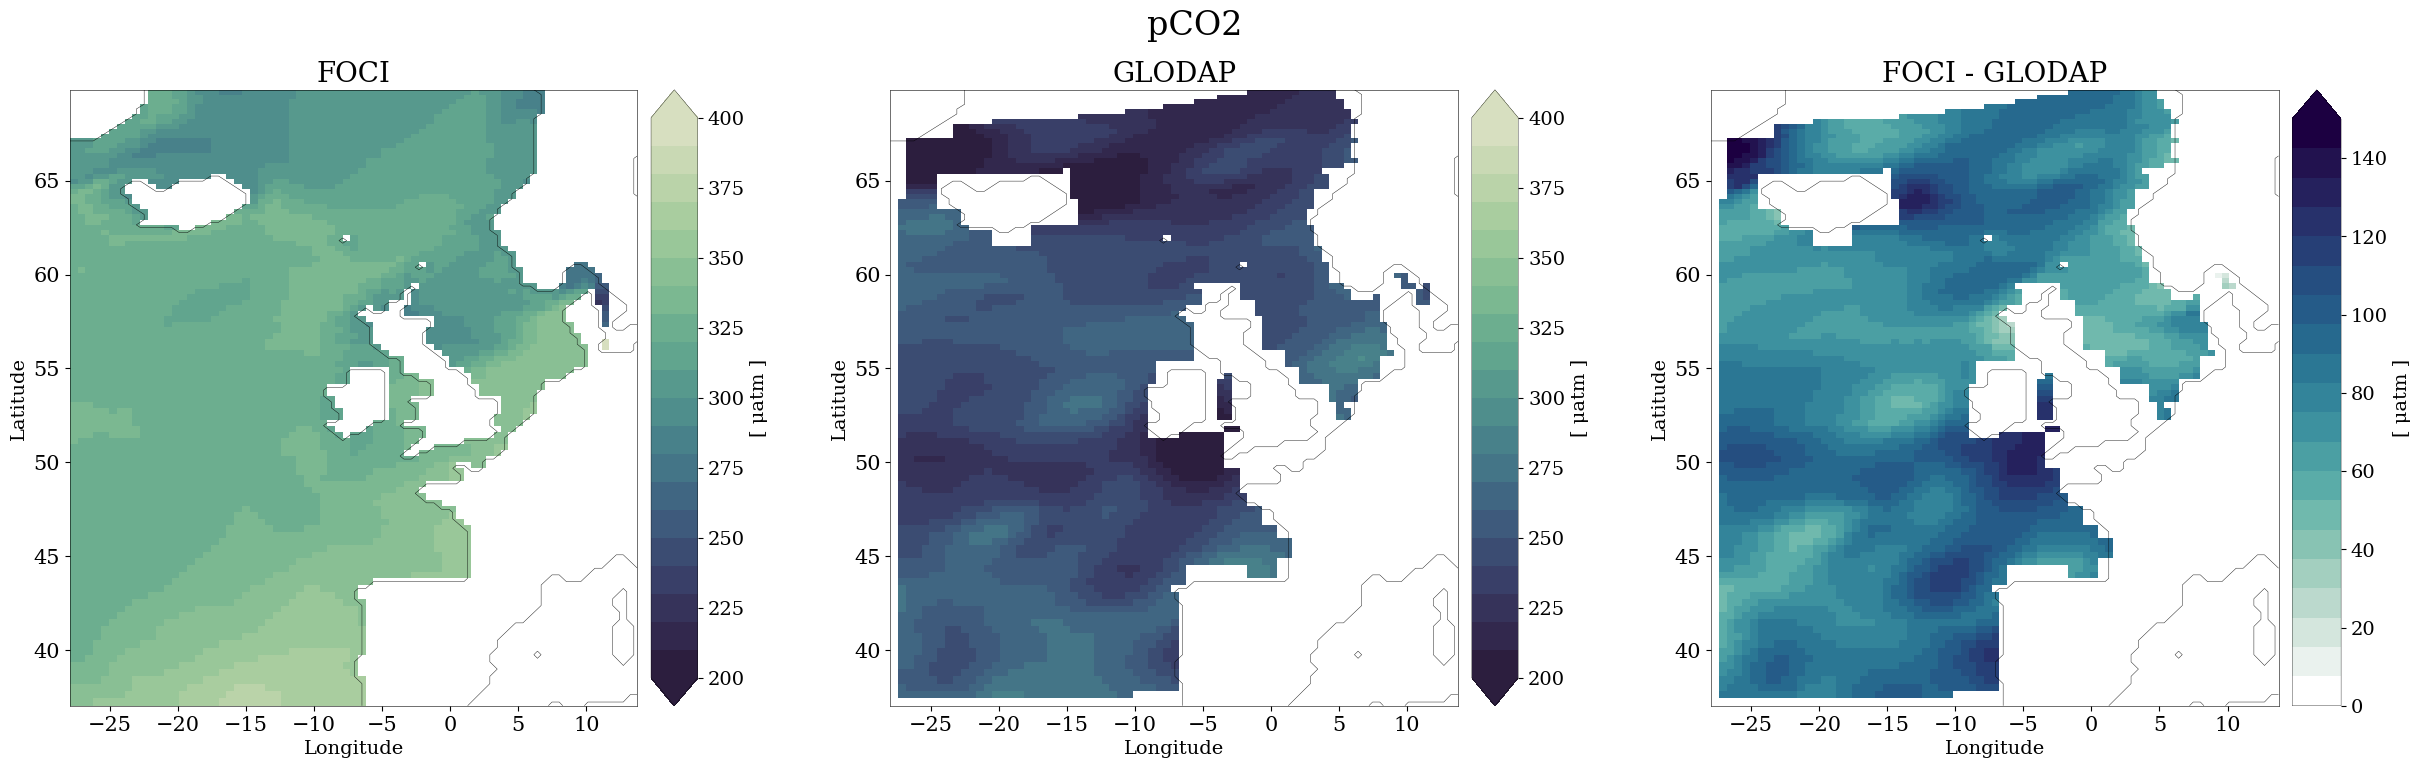

In [6]:
# derived_vars = {
#                     'pCO2':{'unit':'μatm', 'vmin':200, 'vmax':400, 'v_chg':150},
#                     # 'pH':{'unit':'-', 'vmin':8, 'vmax':8.3, 'v_chg':0.25}, 
#                }

# for der, keys in derived_vars.items():
#     unit = keys['unit']
#     v_chg, vmin, vmax = keys['v_chg'], keys['vmin'], keys['vmax']
    
#     def carbonate_chemistry(final, name):
        
#         shape = final['ALK'].shape

#         mask = (
#             np.isfinite(final['ALK']) &
#             np.isfinite(final['DIC']) &
#             np.isfinite(final['SST']) &
#             np.isfinite(final['SSS'])
#         )

#         mask_flat = mask.values.ravel()

#         TA = final['ALK'].values.ravel()[mask_flat]
#         DIC = final['DIC'].values.ravel()[mask_flat]
#         T = final['SST'].values.ravel()[mask_flat]
#         S = final['SSS'].values.ravel()[mask_flat]

#         valid = np.isfinite(TA) & np.isfinite(DIC) & np.isfinite(T) & np.isfinite(S)

#         TA = TA[valid]
#         DIC = DIC[valid]
#         T = T[valid]
#         S = S[valid]

#         kwargs = dict(
#             par1=TA,
#             par2=DIC,
#             par1_type=1,
#             par2_type=2,
#             temperature=T,
#             salinity=S
#         )

#         res = pyco2.sys(**kwargs)
        
#         res_arrays = {}

#         for k, v in res.items():
#             arr = np.full(final['ALK'].size, np.nan)
#             arr[mask_flat] = v
#             res_arrays[k] = xr.DataArray(
#                 arr.reshape(final['ALK'].shape),
#                 dims=final['ALK'].dims,
#                 coords=final['ALK'].coords
#             )

#         return res_arrays[der]

#     FOCI = carbonate_chemistry(FOCI_fin, 'FOCI')
#     GLODAP = carbonate_chemistry(GLODAP_fin, 'GLODAP')
    
#     fig, axes = plt.subplots(1,3, figsize=(30, 8))
#     titles = ['FOCI','GLODAP','FOCI - GLODAP']

#     diff = FOCI - GLODAP
#     for ax, ds, title in zip(axes, [FOCI, GLODAP, diff], titles):

#         ds = ds.where(mesh_mask_sliced)

#         if '-' in title:
#             extend, vmin, vmax = 'max', 0, v_chg
#             cmap = cmap = cm.ocean_r
#         else:
#             extend, vmin, vmax = 'both', vmin, vmax
#             cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True).reversed()
        
#         cmap, norm = create_discrete_cmap(cmap, 20)

#         im = ax.pcolormesh(lat, lon, ds, cmap=cmap, vmin=vmin, vmax=vmax)
#         ax.contour(lat, lon, contour, levels=[0.5], colors='black', linewidths=.3)

#         fineline(ax,0.4)
#         c_map = fig.colorbar(im, ax=ax, 
#             aspect=12,
#             pad=0.02,location='right', extend=extend)

#         c_map.set_label(f'[ {unit} ]', fontsize=14)
#         c_map.outline.set_linewidth(0.25)
#         c_map.ax.tick_params(labelsize=14)

#         ax.set_xlabel('Longitude', fontsize=14)
#         ax.set_ylabel('Latitude', fontsize=14)

#         ax.set_title(title)
#     fig.suptitle(der, fontsize=24)
        
#     plt.savefig(f'/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/validation_{der}.png')